In [16]:
import os
import torch
import numpy as np
import pandas as pd
from PIL import Image
import os
import torch
from transformers import (
    ViTImageProcessor, 
    ViTForImageClassification,
)
from typing import List, Union, Any, Tuple
from matplotlib import pyplot as plt

Definimos una version simplificada del dataset para acelerar los tiempos de la evaluacion mediante batch processing y tensonorizacion.

In [17]:
class EvalDataset(torch.utils.data.Dataset):
    """
    Dataset class to efficiently load data for model evaluation.
    """

    def __init__(
        self,
        dataset_csv: str,
        folder_path: str,
    ):
        """
        Parameters
        ----------
        dataset_csv:str
            Path to a csv file contaning image name and class labels
        folder_path:str
            Path to a folder with all the images
        """
        super().__init__()

        self._folder_path = folder_path
        self._dataset_df = pd.read_csv(dataset_csv, header=None)

    def __getitem__(self, index):

        image_name, class_name = self._dataset_df.loc[index]
        image = Image.open(os.path.join(self._folder_path, image_name))

        return np.asarray(image.convert('RGB')), class_name

    def __len__(self):
        return len(self._dataset_df)

def collate_fn(data: Any):
    """
    Collator function to properly pass raw data without preprocessing
    """
    return tuple(map(list, zip(*data)))

Definimos un wrapper para el modelo de torch para poder devolver probalibilidades junto con las predicciones


In [13]:
class GrassClassificationModel:

    def __init__(
        self,
        model_path:str,
        use_gpu: bool = True,
        use_fp16: bool = False,
        output_attention: bool = False 
    ):
        """
        A wrapper for ViT models for image classification.

        Parameters
        ----------
        model_path:str
            Path where model checkpoint is located.
        use_gpu: bool
            Flag to use nvidia gpu. Enabled by default.
        use_fp16: bool
            Use quantized model to speed up inferece time. Can decrease
            model accuracy.
        output_attention: bool
            Enable the retrieval of attention data from an inference.
        """
        self._use_gpu = use_gpu
        self._use_fp16 = use_fp16
        self._output_attention = output_attention

        self._model = ViTForImageClassification.from_pretrained(model_path, attn_implementation='eager')
        self._transforms = ViTImageProcessor.from_pretrained(model_path)

        self._device = torch.device('cuda' if self._use_gpu else 'cpu')
        self._model.eval()

        if self._use_fp16:
            self._model = self._model.half()
        if use_gpu:
            self._model.to(self._device)

    def run_inference(
            self,
            images: Union[np.ndarray, List[np.ndarray]]
    ) -> Tuple[List[Any], List[float]]:
        """
        Runs inference on the given images.

        Parameters
        ----------
        images: Union[np.ndarray, List[np.ndarray], PIL.Image]
            Accepts a list of images, in BGR color space, as np.ndarray, a 
            single image or a PIL image object list.
        Returns
        -------
        Tuple[List[Any], List[float]] containing class labels and scores.
        """
        with torch.no_grad():
            inputs = self._transforms(images)
            inputs = torch.as_tensor(np.array(inputs['pixel_values']))
            output = self._model(
                pixel_values=inputs.to(self._device), 
                output_attentions=self._output_attention)
            preds = torch.max(output.logits.softmax(-1), dim=-1)
            labels = [
                self._model.config.id2label[id] 
                for id in preds.indices.cpu().tolist()]
        
        if self._output_attention:
            self._attentions = output.attentions

        return labels, preds.values.cpu().tolist()

Evaluacion

                           precision    recall  f1-score   support

              Black-grass       0.74      0.61      0.67        56
                 Charlock       0.99      1.00      0.99        81
                 Cleavers       0.98      0.98      0.98        53
         Common Chickweed       0.97      0.97      0.97       119
             Common wheat       0.95      0.95      0.95        37
                  Fat Hen       0.99      0.99      0.99        98
         Loose Silky-bent       0.84      0.93      0.88       126
                    Maize       1.00      0.97      0.99        36
        Scentless Mayweed       0.97      0.97      0.97       118
          Shepherds Purse       1.00      1.00      1.00        50
Small-flowered Cranesbill       1.00      0.99      1.00       103
               Sugar beet       0.99      0.96      0.97        73

                 accuracy                           0.95       950
                macro avg       0.95      0.94      0.95    

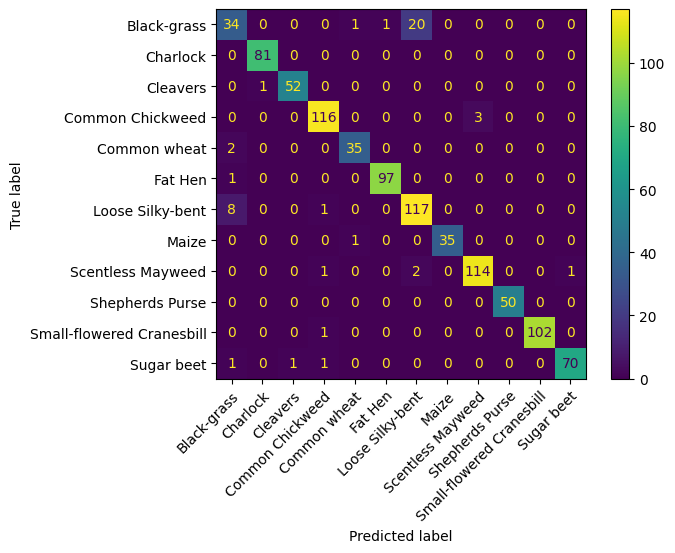

In [18]:
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
collate_fn

val_data_path = './val_data.csv'
image_folder = './data/images/'
model_path = './checkpoint'

dataset = EvalDataset(
    dataset_csv=val_data_path, folder_path=image_folder)
eval_dataloader = DataLoader(
    dataset=dataset, batch_size=64, collate_fn=collate_fn)
model = GrassClassificationModel(model_path=model_path, use_gpu=False)

y_true = list()
y_pred = list()

for images_batch, labels_batch in eval_dataloader:

    preds, _ = model.run_inference(images=images_batch)
    y_true.extend(labels_batch)
    y_pred.extend(preds)

print(classification_report(y_true=y_true, y_pred=y_pred))
disp = ConfusionMatrixDisplay.from_predictions(y_true=y_true, y_pred=y_pred)

plt.setp(disp.ax_.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.show()

Que pasa entre black grass y loose silky-bent?

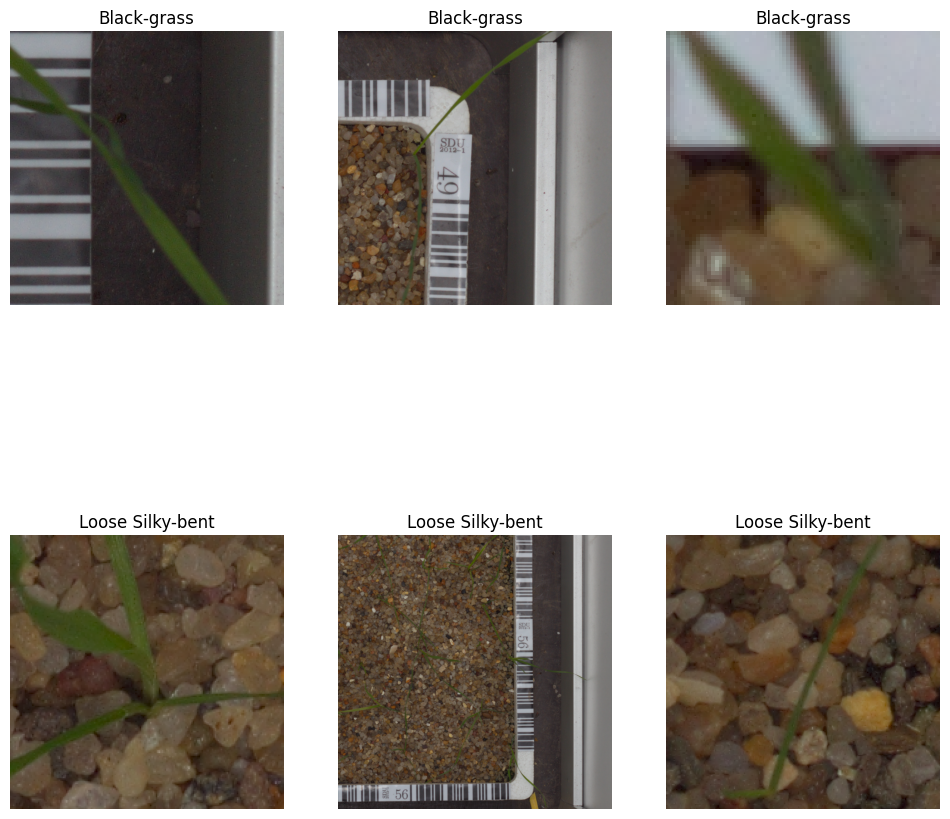

In [22]:
import supervision as sv
import pandas as pd

CSV_PATH = './data/all_images.csv'
image_folder = './data/images/'

qty = 3
black_grass_label = 'Black-grass'
loose_silky_label = 'Loose Silky-bent'
titles = [black_grass_label] * qty + [loose_silky_label] * qty

df = pd.read_csv(CSV_PATH, header=None)
# keep 4 samples of each class
df_filter = df[df[1].isin([black_grass_label, loose_silky_label])]
df_filter = df_filter.groupby(1).apply(lambda x: x.head(qty)).reset_index(drop=True)

images2show = list()

for label in [black_grass_label, loose_silky_label]:
    images_per_class = [
        Image.open(os.path.join(image_folder, name)) 
        for name in df_filter[df_filter[1] == label][0]]
    images2show.extend(images_per_class)
sv.plot_images_grid(images2show, titles=titles, grid_size=(2, qty))
